In [2]:
import pandas as pd


In [4]:
df = pd.read_csv("../datasets/storm_events_damage_modeling_base.csv")
df.head()

/tmp/ipykernel_59325/4151313007.py:1: DtypeWarning: Columns (6,7,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/storm_events_damage_modeling_base.csv")


,EVENT_ID,EPISODE_ID,EVENT_TYPE,CZ_TYPE,STATE,REGION,WFO,SOURCE,YEAR,MONTH,...,TOR_WIDTH,TOR_AREA_KM2,HAS_TORNADO_DATA,TOTAL_DEATHS,TOTAL_INJURIES,TOTAL_CASUALTIES,HAS_FATALITIES,HAS_CASUALTIES,DAMAGE_REAL_2025,DAMAGE_CLASS
0,9981065,NaN,Thunderstorm Wind,C,ARKANSAS,Southeast,NaN,NaN,1970,9,...,0.0,NaN,1,0,0,0,0,0,0.000000,0
1,10058129,NaN,Tornado,C,MISSOURI,Midwest,NaN,NaN,1970,10,...,150.0,0.949169,1,0,0,0,0,0,207538.659794,3
2,10047491,NaN,Thunderstorm Wind,C,MISSISSIPPI,Southeast,NaN,NaN,1970,6,...,0.0,NaN,1,0,0,0,0,0,0.000000,0
3,10056944,NaN,Thunderstorm Wind,C,MISSOURI,Midwest,NaN,NaN,1970,6,...,0.0,NaN,1,0,0,0,0,0,0.000000,0
4,10052308,NaN,Thunderstorm Wind,C,MINNESOTA,Midwest,NaN,NaN,1970,7,...,0.0,NaN,1,0,0,0,0,0,0.000000,0


In [36]:
filtered_df = df[df['EVENT_TYPE'].isin(['Coastal Flood', 'Flood','Flash Flood'])]
filtered_df.head()
filtered_df['FLOOD_CAUSE'].isna().sum()
grouped_counts = filtered_df.groupby('EVENT_TYPE')['FLOOD_CAUSE'].value_counts()
print(grouped_counts)

EVENT_TYPE   FLOOD_CAUSE                 
Flash Flood  Heavy Rain                      71510
             Heavy Rain / Tropical System     2379
             Heavy Rain / Burn Area            957
             Heavy Rain / Snow Melt            275
             Dam / Levee Break                 183
             Ice Jam                            85
             Planned Dam Release                14
Flood        Heavy Rain                      41538
             Heavy Rain / Snow Melt           5504
             Heavy Rain / Tropical System      859
             Ice Jam                           702
             Planned Dam Release               200
             Dam / Levee Break                 100
             Heavy Rain / Burn Area             54
Name: count, dtype: int64


In [39]:
filtered_df = df[df['EVENT_TYPE'].isin(['Coastal Flood'])]
filtered_df['FLOOD_CAUSE'].nunique()


0

--- Top 20 Event Types by Mean Damage (2025 USD) ---
EVENT_TYPE
Hurricane (Typhoon)    1.789764e+08
Storm Surge/Tide       7.074688e+07
Coastal Flood          8.912020e+06
Wildfire               8.326590e+06
Tropical Storm         6.531130e+06
Tsunami                5.365559e+06
Tornado                2.988347e+06
Flash Flood            1.584272e+06
Ice Storm              1.411623e+06
Flood                  1.343605e+06
Drought                9.935227e+05
Debris Flow            8.245260e+05
Frost/Freeze           7.674193e+05
Lakeshore Flood        5.414674e+05
Cold/Wind Chill        3.939489e+05
High Wind              3.567703e+05
Hail                   2.221785e+05
Blizzard               2.070841e+05
Tropical Depression    2.012730e+05
Volcanic Ash           1.818746e+05
Name: DAMAGE_REAL_2025, dtype: float64




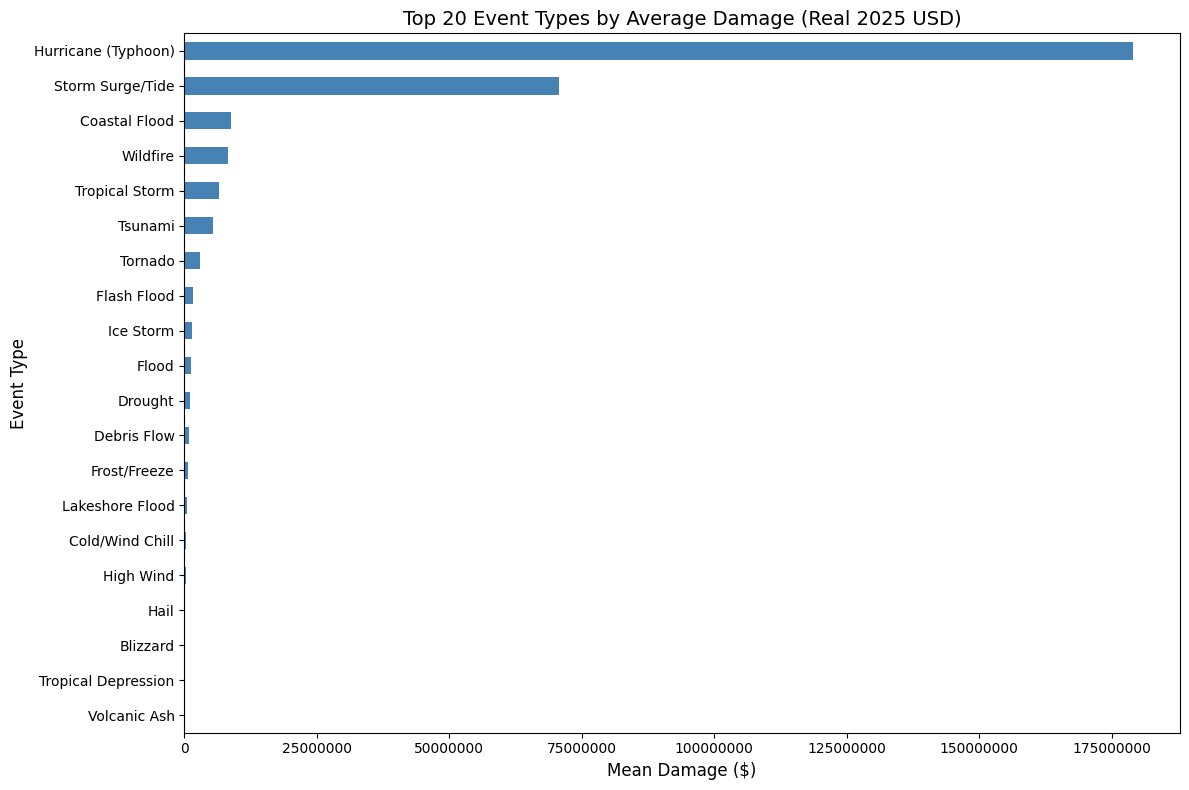

In [43]:
import matplotlib.pyplot as plt

# 1. Calculate the mean, sort it descending, and grab the top 20
top_20_damages = df.groupby('EVENT_TYPE')['DAMAGE_REAL_2025'].mean().sort_values(ascending=False).head(20)

print("--- Top 20 Event Types by Mean Damage (2025 USD) ---")
print(top_20_damages)
print("\n")

# 2. Plotting the results
plt.figure(figsize=(12, 8))

# Note: We sort ascending here just for the plot so the largest bar appears at the very top of the chart
top_20_damages.sort_values(ascending=True).plot(kind='barh', color='steelblue')

plt.title('Top 20 Event Types by Average Damage (Real 2025 USD)', fontsize=14)
plt.xlabel('Mean Damage ($)', fontsize=12)
plt.ylabel('Event Type', fontsize=12)

# Formats the x-axis to show regular numbers instead of scientific notation (e.g., 1e8)
plt.ticklabel_format(style='plain', axis='x') 

plt.tight_layout()
plt.show()